# Diplomado en Sismología
## Tarea Módulo "Características Cuantitativas de la Fuente Sísmica"

**Profesor:** Francisco Bravo Sagua  
**Estudiante:** _________________________  
**Fecha:** ______________________________

---

## Descripción

En esta tarea se estudiará de manera práctica la **modelación de sismogramas en campo lejano** mediante un código numérico proporcionado junto con este notebook.

Se analizará a modo de ejemplo el terremoto de Colombia Mw 7.4 del 10 de Agosto de 2026. Las actividades deben ser desarrolladas en este archivo y entregado en  u-cursos en los plazos
establecidos por su profesor

### Modo de uso

Las actividades se pueden ejecutar de dos maneras:

- Descargando el repositorio y ejecutando este notebook desde su computador personal, ó,
- Desde una sesión virtual en linea, como puede ser en `mybinder.org`

Para utilizarlo en su computador personal, se requiere un editor de jupyther notebook y tener instalado python.
Al utilizar la segunda opción, debe considerar que la sesión se elimina después de ser cerrada, por lo que los archivos no son permanentes.
Ud debe descargar este archivo antes de cerrar sesión. Además, la sesiób virtual se cierra después de 10 minutos de inactividad, por lo que se recomienda
ir anotando los resultados previos para no perder el trabajo realizado

Este notebook se compone de celdas de texto y celdas con código. Para editar una celda con texto se debe hacer doble click sobre ella y presionar `shift + Enter`.
Para editar las celdas de código basta con situar el puntero sobre la región que desea modificar. Para ejecutar las instrucciones de la celda de código se presiona `shift + Enter`.

## Actividad 1

1 - Ingrese a la página https://earthquake.usgs.gov/earthquakes/eventpage/us6000tjl2/executive . Busque el apartado con el reporte del tensor de momento sísmico del terremoto.<br>
Reporte la magnitud, el momento sísmico, profundidad, half duration y la geometría de los planos nodales.

**Magnitud** : ________

**Momento Sísmico**:______

**Profundidad**:______

**Half duration**:______

**Geometría plano 1**:__________

**Geometría plano 2**:__________

2 - Ingrese al apartado con la solución de la falla finita. Descarge en su computador las imagenes "Cross-section of slip distribution" y "Moment rate function".

- A partir de la imagen "Cross-section", haga una estimación del área de ruptura (en metros al cuadrado) y del deslizamiento promedio (metros).<br>
 Haga una estimación del momento sísmico, considerando $\mu = 10^{10} \text{N}/m^2$. Calcule la magnitud Mw para ese momento sísmico.

 - A partir del gráfico "Moment rate function", estime la duración del evento. ¿Cómo se relaciona este valor con el half duration del tensor de momento?

## Actividad 2

1- Ejecute la celda siguiente para cargar 2 sismogramas observados y sintéticos  del terremoto de Colombia 

In [34]:
import matplotlib.pyplot as plt
from scipy.ndimage import shift

# Lectura sismogramas reales
shel = np.loadtxt('SHEL_obs.txt')
tuc = np.loadtxt('TUC_obs.txt')

## Lectura sismogramas sintéticos
import numpy as np
mod = np.loadtxt('SHEL.0')
mod_tuc = np.loadtxt('TUC.0')

2 - Modele la fuente sísmica como una secuencia de 4 pulsos donde se libera momento sísmico.
Las variables t1, t2, t3, t4 representan los tiempos donde se libera el pulso de momento sísmico
y las variables amp1, amp2, amp3, amp4 las amplitudes de estos pulsos. Elija una combinación tal que el gráfico de los sismogramas sintéticos se parezca
lo más posible a los sismogramas observados.

Recomendación: Parta determinando la amplitud y el tiempo del pulso mayor que se observa en los sismogramas

In [35]:
amp1, amp2, amp3, amp4 = 1,1,1,1
t1, t2, t3, t4 =  10,20,30,40

Gráfico observados vs sintéticos

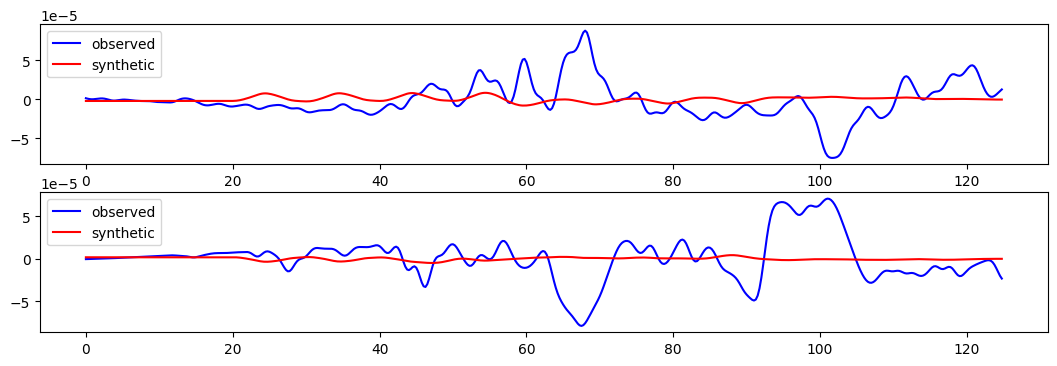

In [36]:
m = [amp1, amp2, amp3, amp4]
d = np.array([t1, t2, t3, t4])

fig = plt.figure(figsize=(13,4))

i=0
for obs ,modi in zip([shel[:500], tuc[:500]], [mod[:500,1], mod_tuc[:500,1]]):

    ax1 = fig.add_subplot(2,1,i+1)

    A = np.column_stack([shift(modi, shift=di*4, mode='nearest') for di in d])
    ms  = [mi for mi in m]

    fwd = np.matmul(A, ms)

    t = np.arange(0,len(modi))*0.25
    
    plt.plot(t, obs, 'b', label='observed')
    plt.plot(t, fwd, 'r', label='synthetic')
    plt.legend(loc='upper left')

    i+=1


### Gráfico función temporal

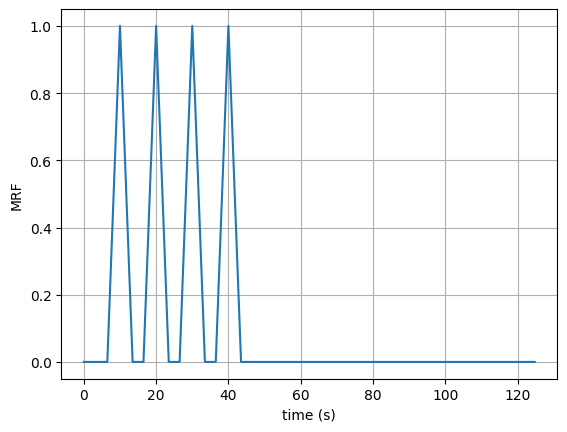

In [37]:
y = 0
t = np.arange(0, 500)*0.25

for mi, di in zip(m,d):
    centro, ancho = di, 7
    y += np.maximum(1.0 - np.abs(t - centro) / (ancho / 2.0), 0.0)*mi

# Gráfico
plt.plot(t, y)
plt.xlabel('time (s)')
plt.ylabel('MRF')
plt.grid()
plt.show()

3 - Si cada sismogramas sintéticos fue generado con un pulso de momento sísmico 10**19 Nm, calcule el momento sísmico y la magnitud de momento de todo el proceso de ruptura. <br>
Utilice la celda para sus cálculos

In [38]:
from numpy import log10 as log

M0 = _
# ingrese aća el valor de M0 y la formula para calcular Mw
Mw = log(23 + 24)
print(M0)
print(Mw)



1.6720978579357175


4 - Responda las siguientes preguntas

- ¿Cuál es la duración del terremoto?
- Compare la función temporal fuente que determinó con la función temporal fuente publicada en el modelo de falla finita de la página del USGS.<br>
Indique diferencias y similitudes.
